# Labwork 4 -- 2D grid for grayscale
Le Nghiem Thanh Thuy - 2540023

In [51]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from skimage import data

print("CUDA available:", cuda.is_available())

CUDA available: True


In [52]:
img = data.astronaut()
height, width, channels = img.shape
pixelCount = height * width
print("Image shape:", img.shape, "-> pixels:", pixelCount)

# the 1D version still needs the flat image
flatSrc = img.reshape(pixelCount, channels)

Image shape: (512, 512, 3) -> pixels: 262144


## 1. The two kernels

In [53]:
@cuda.jit
def grayscale1D(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
   # if tidx < src.shape[0]:
    g = (src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) // 3
    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


@cuda.jit
def grayscale2D(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x  # column
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y  # row
    #if tidx < src.shape[1] and tidy < src.shape[0]:
    g = (src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) // 3
    dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

## 2. Check that both give the same image

In [54]:
# 1D arrays on the device
devSrc1D = cuda.to_device(flatSrc)
devDst1D = cuda.device_array((pixelCount, channels), np.uint8)

# 2D arrays on the device
devSrc2D = cuda.to_device(img)
devDst2D = cuda.device_array((height, width, channels), np.uint8)

blockSize1D = 64
gridSize1D = (pixelCount + blockSize1D - 1) // blockSize1D

blockSize2D = (16, 16)
gridSize2D = ((width + blockSize2D[0] - 1) // blockSize2D[0],
              (height + blockSize2D[1] - 1) // blockSize2D[1])

grayscale1D[gridSize1D, blockSize1D](devSrc1D, devDst1D)
grayscale2D[gridSize2D, blockSize2D](devSrc2D, devDst2D)
cuda.synchronize()

out1D = devDst1D.copy_to_host().reshape(height, width, channels)
out2D = devDst2D.copy_to_host()

print("1D and 2D give the same image:", np.array_equal(out1D, out2D))

1D and 2D give the same image: True


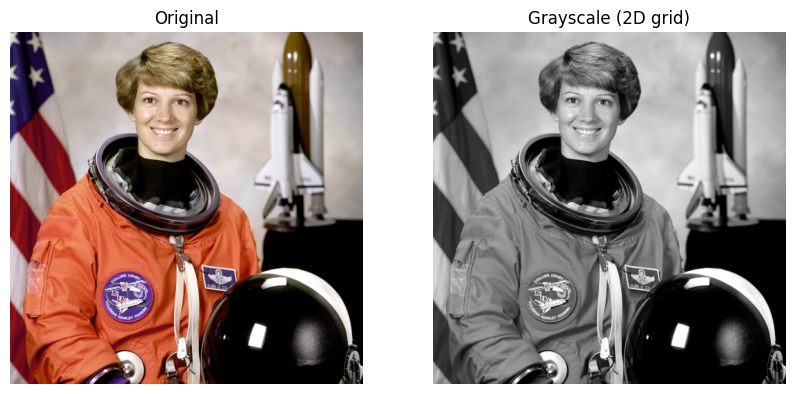

In [55]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Grayscale (2D grid)")
plt.imshow(out2D)
plt.axis("off")
plt.show()

## 3. Timing


In [56]:
nRuns = 100

def bench(kernel, gridSize, blockSize, devSrc, devDst):
    # warm-up, not measured
    kernel[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()

    start = time.time()
    for _ in range(nRuns):
        kernel[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()
    return (time.time() - start) / nRuns

### 1D block sizes

In [ ]:
lsBlockSizes1D = [32, 64, 128, 256, 512, 1024]

lsTimes1D = []
for blockSize in lsBlockSizes1D:
    gridSize = pixelCount // blockSize
    t = bench(grayscale1D, gridSize, blockSize, devSrc1D, devDst1D)
    lsTimes1D.append(t)
    print(f"1D {blockSize:4d}        ({blockSize:4d} threads)  "
          f"grid {gridSize:10d}  ->  {t * 1000:.4f} ms")

1D   32        (  32 threads)  grid       8192  ->  0.0684 ms
1D   64        (  64 threads)  grid       4096  ->  0.0765 ms
1D  128        ( 128 threads)  grid       2048  ->  0.0690 ms
1D  256        ( 256 threads)  grid       1024  ->  0.0607 ms
1D  512        ( 512 threads)  grid        512  ->  0.0610 ms
1D 1024        (1024 threads)  grid        256  ->  0.0801 ms


### 2D block sizes
A block cannot have more than 1024 threads, so for example $(32, 32)$ is allowed but
$(32, 64)$ is not.

In [ ]:
lsBlockSizes2D = [(8, 8), (16, 8), (16, 16), (32, 8), (16, 32), (32, 32), (64, 16)]

lsTimes2D = []
for blockSize in lsBlockSizes2D:
    gridSize = (width  // blockSize[0],
                height // blockSize[1])
    t = bench(grayscale2D, gridSize, blockSize, devSrc2D, devDst2D)
    lsTimes2D.append(t)
    print(f"2D {str(blockSize):9s} ({blockSize[0] * blockSize[1]:4d} threads)  "
          f"grid {str(gridSize):10s}  ->  {t * 1000:.4f} ms")

2D (8, 8)    (  64 threads)  grid (64, 64)    ->  0.0993 ms
2D (16, 8)   ( 128 threads)  grid (32, 64)    ->  0.0469 ms
2D (16, 16)  ( 256 threads)  grid (32, 32)    ->  0.0411 ms
2D (32, 8)   ( 256 threads)  grid (16, 64)    ->  0.0402 ms
2D (16, 32)  ( 512 threads)  grid (32, 16)    ->  0.0375 ms
2D (32, 32)  (1024 threads)  grid (16, 16)    ->  0.0376 ms
2D (64, 16)  (1024 threads)  grid (8, 32)     ->  0.0404 ms


## 4. Comparison

In [59]:
best1D = min(zip(lsTimes1D, lsBlockSizes1D))
best2D = min(zip(lsTimes2D, lsBlockSizes2D))

print(f"Best 1D : block {str(best1D[1]):9s} ->  {best1D[0] * 1000:.4f} ms")
print(f"Best 2D : block {str(best2D[1]):9s} ->  {best2D[0] * 1000:.4f} ms")
print(f"2D takes {best2D[0] / best1D[0]:.2f}x the time of 1D")

Best 1D : block 256       ->  0.0607 ms
Best 2D : block (16, 32)  ->  0.0375 ms
2D takes 0.62x the time of 1D


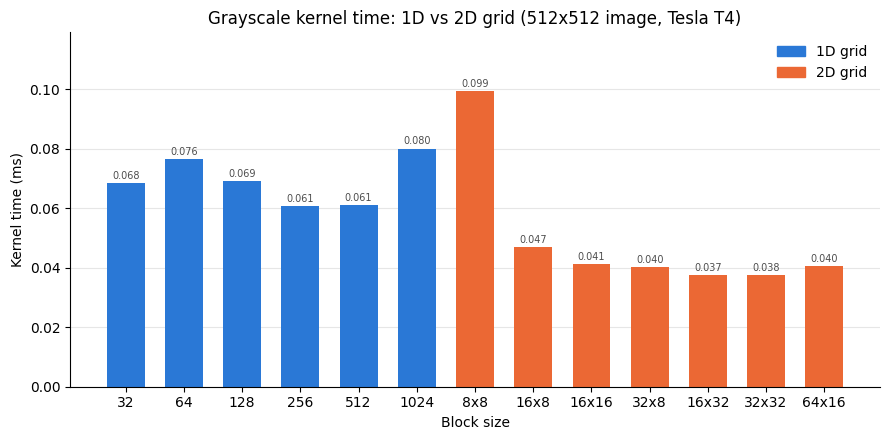

In [60]:
labels = [f"{b}" for b in lsBlockSizes1D] + [f"{b[0]}x{b[1]}" for b in lsBlockSizes2D]
timesMs = [t * 1000 for t in lsTimes1D] + [t * 1000 for t in lsTimes2D]
colors = ["#2a78d6"] * len(lsTimes1D) + ["#eb6834"] * len(lsTimes2D)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, timesMs, width=0.65, color=colors)

ax.set_title("Grayscale kernel time: 1D vs 2D grid (512x512 image, Tesla T4)")
ax.set_xlabel("Block size")
ax.set_ylabel("Kernel time (ms)")

ax.set_ylim(0, max(timesMs) * 1.20)
ax.grid(axis="y", color="0.9")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, t in zip(bars, timesMs):
    ax.annotate(f"{t:.3f}",
                (bar.get_x() + bar.get_width() / 2, t),
                textcoords="offset points", xytext=(0, 3),
                ha="center", fontsize=7, color="0.3")

handles = [plt.Rectangle((0, 0), 1, 1, color="#2a78d6"),
           plt.Rectangle((0, 0), 1, 1, color="#eb6834")]
ax.legend(handles, ["1D grid", "2D grid"], frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("blocksize2d.png", dpi=150)
plt.show()